# 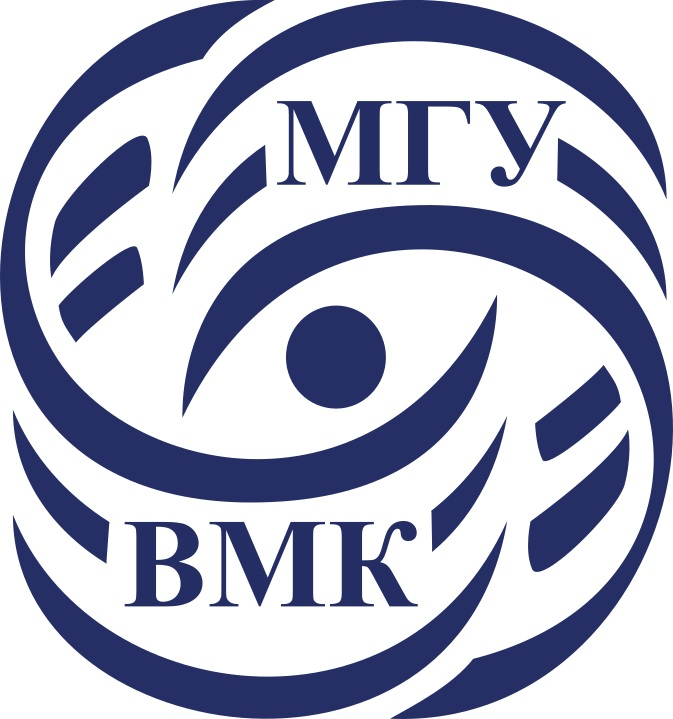

# Машинное обучение. ВМК МГУ

# Практическое задание 3: Линейные модели: регрессия

## Уровень: <font color='MediumSeaGreen'>**Исследовательский (Research)**</font>

# О формате сдачи

🔷 **<font color='plum'>При решении ноутбука используйте данный шаблон</font>**

    ✅ Можно добавлять новые ячейки любых типов
    ❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий


🔷 **<font color='plum'>При оценивании задач учитывается код</font>**

    ✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
    ❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
    ❌ Наличе работоспособного кода в ноутбуке, если на сказано иного, обязательно

🔷 **<font color='plum'>При оценивании задач учитываются выводы</font>**

    ✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
    ✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
    ✅ Сопутствующие изображения, графики, таблички - приветствуются!
    ❌ При отсутствии выводов задание не засчитается на полный балл

-----------
<font color="white" style="opacity:0.2025"></font>







Цель данного задания:

* Узнать, что такое переобучение и как с ним бороться в линейных моделях;
* Понять, чем отличаются разные регуляризаторы;
* Научиться решать задачу регрессии линейными моделями.
-------
<font color=DarkOrange>**Примерное время выполнения (execution time/время выполнения, если нажать run all) всех ячеек ноутбука при правильной реализации: 7 минут </font>**

# Подготовка рабочей среды

Сначала установим нужные нам версии библиотек. Мы гарантируем, что в данных версиях задание будет корректно отрабатывать.

После установки нужных версий, **возможно,** нужно перезагрузить среду (runtime), но скорее всего вам это не понадобится


На скачивание файла и установку понадобится не более 5 минут.

<font color='OrangeRed'>**Важно!**</font>

Устанавливать нужные версии нужно каждый раз, когда создается новый рантайм. Например, если вы 2 часа подряд делаете это задание, то подготовить библиотеки достаточно 1 раз. Но если вы, например, начали в понедельник, затем закрыли/выключили ноутбук, то при продолжении в среду, вам нужно будет запустить рантайм заново и следовательно заново установить библиотеки.

<font color='OrangeRed'>**Важно!**</font>
Если вы предпочитаете делать практические задания на своем личном ноутбуке, то проверьте, что вы установили рабочее окружение в [соответствии с гайдом](https://github.com/MSU-ML-COURSE/ML-COURSE-24-25/blob/main/tutorials/%D0%A2%D1%83%D1%82%D0%BE%D1%80%D0%B8%D0%B0%D0%BB%20%D0%BF%D0%BE%20%D1%83%D1%81%D1%82%D0%B0%D0%BD%D0%BE%D0%B2%D0%BA%D0%B5%20%D1%80%D0%B0%D0%B1%D0%BE%D1%87%D0%B5%D0%B3%D0%BE%20%D0%BE%D0%BA%D1%80%D1%83%D0%B6%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%B2%20Python%20%D0%B4%D0%BB%D1%8F%20%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%20(2).pdf)


In [208]:
! pip install -q -r ./requirements_2025_26_for_colab_small.txt

Проверим версию библиотеки:

In [209]:
import catboost
assert(catboost.__version__ == '1.2.8')

Теперь можно приступать к выполнению задания! :)

-----------
<font color="white" style="opacity:0.2025"></font>

In [210]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter("ignore")
sns.set(style="darkgrid")
%matplotlib inline

## Линейная регрессия и регуляризация

Напомним, что линейная регрессия — это модель следующего вида: $$a(x) = \langle w, x \rangle + b$$ где $w \in \mathbb{R}^d$, $b \in \mathbb{R}$. Обучить линейную регрессию — значит найти $w$ и $b$.

В модели линейной регрессии с $l_2$ регуляризацией мы оптимизируем следующий функционал:

$\frac{1}{N} \cdot ∑_{i=1}^N (w_1 \cdot x_{i1} + \dots w_n \cdot x_{in} + b - y_i)^2 + \frac{\alpha}{2} \cdot \left( w_1^2 + \dots + w_n^2 \right) \rightarrow \min_{w_1, \dots, w_n, b}$

В модели линейной регрессии с $l_1$ регуляризацией мы оптимизируем следующий функционал:

$\frac{1}{N} \cdot ∑_{i=1}^N (w_1 \cdot x_{i1} + \dots w_n \cdot x_{in} + b - y_i)^2 + \alpha \cdot \left( |w_1| + \dots + |w_n| \right) \rightarrow \min_{w_1, \dots, w_n, b}$

### <font color='DarkOrange'>**Задание 1 [1 балл]**</font>

Почему при обучении линейных моделей, коэффициент $b$ не регуляризуется? Дайте ответ с опорой на лекции. Возможно вам также поможет картика из базовой части

<font color='MediumOrchid'>**Ваши выводы тут:**</font>

Потому что его нет в регуляризаторе, поэтому свободный член не регуляризуется

-----
<font color="white" style="opacity:0.2025"></font>

Рассмотрим модель линейной регрессии с $l_2$ регуляризацией. В sklearn эта модель реализована посредством класса Ridge. В нём есть методы fit и predict. Первый принимает на вход обучающую выборку и вектор целевых переменных и обучает модель, второй, будучи вызванным после обучения модели, возвращает предсказание на выборке.

Сгенерируем случайные данные. Пусть $x$ будет обычным числом из равномерного распределения, а $𝑦=0.5 \cdot x + 0.1$ &mdash; целевая переменная. При этом наблюдаем мы $\overline{y} = y + \varepsilon,~\varepsilon \sim N(0, 0.01)$. Добавим в данные к переменной $x$ её же умноженную на $3$. То есть, теперь у нас два признака $x_1$ и $x_2 = 3 \cdot x_1$.

Поскольку  $y = c \cdot 0.5 \cdot x_1 + \frac{1 - c}{6} \cdot x_2 + 0.1$, где $c$ любое сколь угодно большое вещественное число. То, как мы могли убедиться в базовой части, без регуляризации есть риск выучить очень большие веса.

Посмотрим, как меняется значения весов, в зависимости от значения коэффициента регуляризации.

In [211]:
from sklearn.linear_model import Ridge

In [229]:
np.random.seed(1)
X = np.random.uniform(0, 1, 100)
Y = X * 0.5 + 0.1 + np.random.randn(100) * 0.1

X3 = np.hstack((X[:, None], 3 * X[:, None]))
Y3 = X3[:, 0] * 0.5 + 0.1 + np.random.randn(100) * 0.1

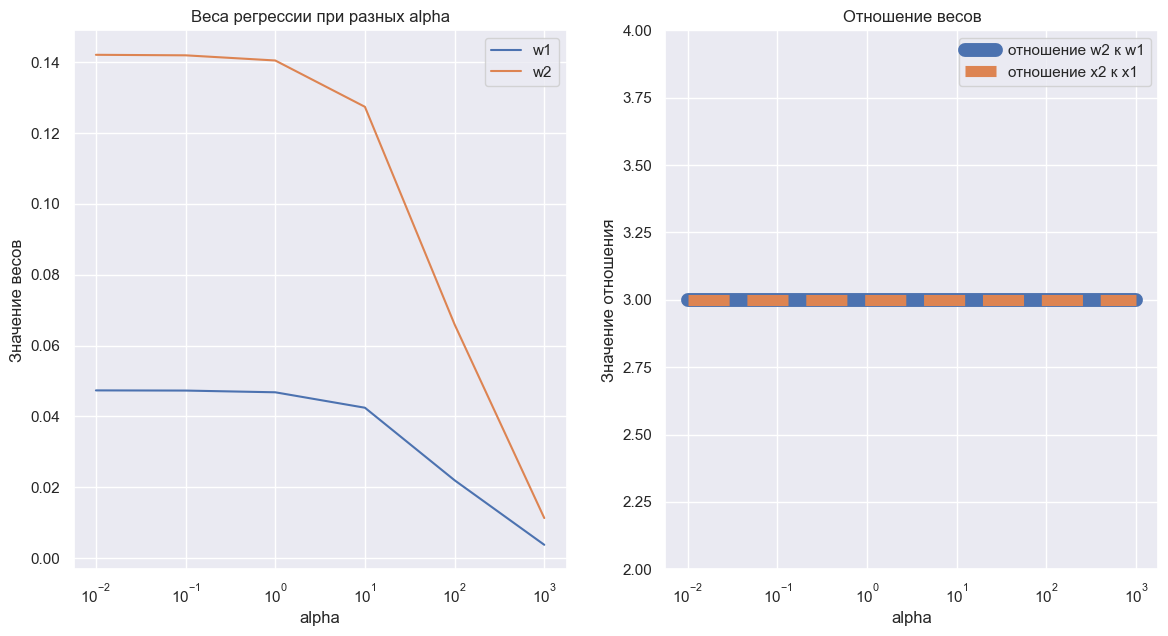

In [213]:
w1 = []
w2 = []

alphas = [0.01, 0.1, 1, 10, 100, 1000]

for alpha in alphas:
    reg = Ridge(alpha=alpha)
    reg.fit(X3, Y3)
    w1.append(reg.coef_[0])
    w2.append(reg.coef_[1])

w1 = np.array(w1)
w2 = np.array(w2)

fig, axs = plt.subplots(figsize=(14, 7), ncols=2)
axs[0].plot(alphas, w1, label="w1")
axs[0].plot(alphas, w2, label="w2")
axs[0].set_xscale("log")
axs[0].set_title("Веса регрессии при разных alpha")
axs[0].set_xlabel("alpha")
axs[0].set_ylabel("Значение весов")
axs[0].legend()
axs[1].plot(alphas, w2 / w1, label="отношение w2 к w1", linewidth=10)
axs[1].plot([0.01, 1000], [3, 3], label="отношение x2 к x1", linestyle="--", linewidth=8)
axs[1].set_xscale("log")
axs[1].set_ylim(2,4)
axs[1].set_xlabel("alpha")
axs[1].set_ylabel("Значение отношения")
axs[1].set_title("Отношение весов")
axs[1].legend()
plt.show()

### <font color='DarkOrange'>**Задание 2 [2 баллa]**</font>

Как думаете, почему отношение между весами постоянно? (подсказка, необходимо выписать функцию потерь и посчитать производные по весам)

<font color='MediumOrchid'>**Ваши выводы тут:**</font>

Для Ridge функция потерь имеет вид:
$$
L(w_1,w_2,b)=\sum_{i=1}^{n}\left(y_i-(w_1x_i+3w_2x_i+b)\right)^2+\lambda\,(w_1^2+w_2^2).
$$

Производные по весам:
$$
\frac{\partial L}{\partial w_1}=-2\sum_{i=1}^{n}x_i\left(y_i-(w_1x_i+3w_2x_i+b)\right)+2\lambda w_1,
$$
$$
\frac{\partial L}{\partial w_2}=-2\sum_{i=1}^{n}3x_i\left(y_i-(w_1x_i+3w_2x_i+b)\right)+2\lambda w_2.
$$

В оптимуме:
$$
\frac{\partial L}{\partial w_1}=0, \qquad \frac{\partial L}{\partial w_2}=0.
$$

Считаем комбинацию:
$$
3\frac{\partial L}{\partial w_1}-\frac{\partial L}{\partial w_2}=0.
$$

Квадратичная часть сокращается и остается:
$$
2\lambda\,(3w_1-w_2)=0.
$$

При $\lambda>0$ получаем:
$$
3w_1-w_2=0 \;\Rightarrow\; \frac{w_2}{w_1}=3.
$$


-----
<font color="white" style="opacity:0.2025"></font>

Заметим, что при $l_2$ регуляризации в данном примере веса получились пропорциональны значениям признаков. При этом, мы знаем, что оба признака взаимно однозначны, и прогноз можно делать только по одному из них. Для этого придумана $l_1$ регуляризация. В билиотеке sklearn линейная регрессия с $l_1$ регуляризацией реализована в классе Lasso

### <font color='DarkOrange'>**Задание 3 [2 баллa]**</font>

Почему в нашем примере $l_1$ регуляризация приведёт к разреживанию весов? (подсказка, нужно опять подсчитать производную, но обратите внимание на дифференцируемость модуля).

<font color='MediumOrchid'>**Ваши выводы тут:**</font>

Пусть для Lasso функция потерь:
$$
L(w_1,w_2,b)=\sum_{i=1}^{n}\left(y_i-(w_1x_i+w_2\cdot 3x_i+b)\right)^2+\lambda\left(|w_1|+|w_2|\right).
$$

Тогда (в терминах субградиента)
$$
\frac{\partial L}{\partial w_1}=-2\sum_{i=1}^{n}x_i\left(y_i-(w_1x_i+3w_2x_i+b)\right)+\lambda\,\operatorname{sgn}(w_1),
$$
$$
\frac{\partial L}{\partial w_2}=-2\sum_{i=1}^{n}3x_i\left(y_i-(w_1x_i+3w_2x_i+b)\right)+\lambda\,\operatorname{sgn}(w_2).
$$

В оптимуме приравниваем к нулю и считаем комбинацию
$$
3\frac{\partial L}{\partial w_1}-\frac{\partial L}{\partial w_2}=0.
$$

Квадратичная часть сокращается, остаётся
$$
a\,(3\,\operatorname{sgn}(w_1)-\operatorname{sgn}(w_2))=0,
$$
где $a=\lambda$ (с точностью до константного множителя в определении функции потерь).

Также учитываем, что $\operatorname{sgn}(0)=[-1,1]$, поэтому в точке нуля возможен субградиент, и один из весов может стать ровно нулевым.

Предположим, что это не так, то есть оба веса ненулевые. Тогда $\operatorname{sgn}(w_1),\operatorname{sgn}(w_2)\in\{-1,1\}$ и
$$
a\,(3\,\operatorname{sgn}(w_1)-\operatorname{sgn}(w_2))\in\{-4a,-2a,2a,4a\},
$$
а значит не может равняться 0 (при $a\neq 0$). Получаем противоречие. Следовательно, один из весов должен равняться 0.

-----

Добавим $l_1$ регуляризацию и посмотрим, как меняется значения весов, в зависимости от значения коэффициента регуляризации.

In [214]:
from sklearn.linear_model import Lasso

In [241]:
reg = Lasso(alpha=1., max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 1.")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

reg = Lasso(alpha=0.1, max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 0.1")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

reg = Lasso(alpha=0.01, max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 0.01")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

reg = Lasso(alpha=0.001, max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 0.001")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

reg = Lasso(alpha=0.0001, max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 0.0001")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

reg = Lasso(alpha=0.00001, max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 0.00001")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

Веса, при alpha = 1.
w1: 0.0 	w2: 0.0

Веса, при alpha = 0.1
w1: 0.0 	w2: 0.029684463509327002

Веса, при alpha = 0.01
w1: 0.0 	w2: 0.145061609172485

Веса, при alpha = 0.001
w1: 0.0 	w2: 0.15659932373880084

Веса, при alpha = 0.0001
w1: 0.0 	w2: 0.15775309519543243

Веса, при alpha = 0.00001
w1: 0.3966873199145448 	w2: 0.02563936570291395



### <font color='DarkOrange'>**Задание 4 [2 баллa]**</font>

Почему в итоге при $\alpha = 0.00001$ получились веса не равные нулю?

<font color='LightSteelBlue'>**Подсказка**</font>

 Обратите внимание на то, каким странным получился вес $w_2$

<font color='MediumOrchid'>**Ваши выводы тут:**</font>

Вообще говоря, один из весов должен быть равен нулю, исходя из предыдущего задания,но видимо из-за параметров лассо (tol, x_iter, хотя tol по умолчанию равен 1e-4) и из-за маленького альфа, который делает вклад штрафа минимальным. СЛдеующие 3 фрагмента показывают, что веса зануляются из-за максимального количества итераций

In [242]:
reg = Lasso(alpha=0.00001, max_iter = 100000, tol=1e-4)
reg.fit(X3, Y3)
print(f"Веса, при alpha = 0.00001:")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print("b:", reg.intercept_)

Веса, при alpha = 0.00001:
w1: 0.0 	w2: 0.15786847234109558
b: 0.12416588448060217


In [243]:
reg = Lasso(alpha=0.00001, max_iter = 1000, tol=1e-7)
reg.fit(X3, Y3)
print(f"Веса, при alpha = 0.00001:")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print("b:", reg.intercept_)

Веса, при alpha = 0.00001:
w1: 0.3966873199145448 	w2: 0.02563936570291395
b: 0.12416588448060228


-----

In [244]:
reg = Lasso(alpha=0.00001, max_iter = 100000, tol=1e-7)
reg.fit(X3, Y3)
print(f"Веса, при alpha = 0.00001:")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print("b:", reg.intercept_)

Веса, при alpha = 0.00001:
w1: 0.0 	w2: 0.15786847234109558
b: 0.12416588448060217


В предущих блоках мы использовали модельные примеры, в которых $y$ зависел от $x$ линейно. Но так бывает далеко не всегда.

### <font color='DarkOrange'>**Задание 5 [1 баллa]**</font>

 Придумайте, сгенерируйте и визуализируйте пример, в котором линейная регрессия будет плохо классифицировать данные.

Коэффициенты линейной регрессии (1D):
w1: 0.0240933343516163
b: -1.8986587925605578
MSE: 4810.693187177135
R2: 0.0006223185179818902


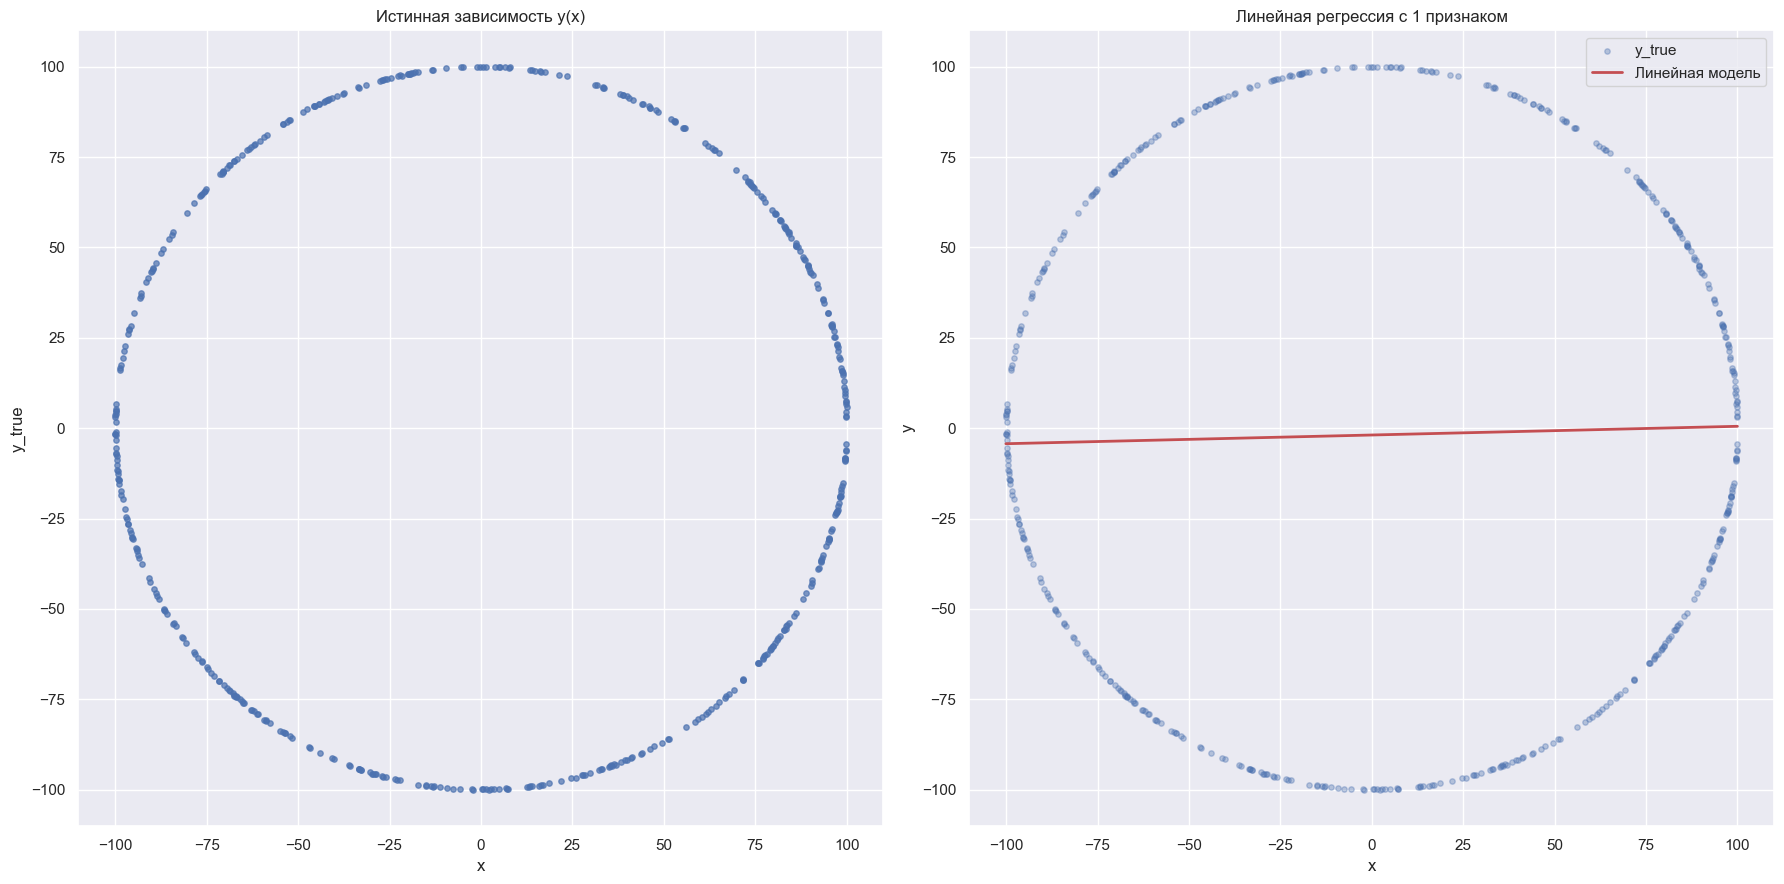

In [246]:
np.random.seed(42)
n = 500
eps = 0.15

theta = np.random.uniform(0, 2 * np.pi, n)
r = 100 + np.random.uniform(-eps, eps, n)

x = r * np.cos(theta)
y = r * np.sin(theta)

# Одномерный случай: в модели только один признак x -> один вес w1
X5 = x[:, None]

# Регрессионный таргет: y-координата точки на (почти) окружности
y5 = y

lin_reg = Ridge(alpha=0)
lin_reg.fit(X5, y5)
y5_pred = lin_reg.predict(X5)

mse5 = np.mean((y5_pred - y5) ** 2)
r2_5 = 1 - np.sum((y5_pred - y5) ** 2) / np.sum((y5 - y5.mean()) ** 2)

print("Коэффициенты линейной регрессии (1D):")
print("w1:", lin_reg.coef_[0])
print("b:", lin_reg.intercept_)
print("MSE:", mse5)
print("R2:", r2_5)

fig, axs = plt.subplots(1, 2, figsize=(18, 9))

axs[0].scatter(X5[:, 0], y5, s=15, alpha=0.7)
axs[0].set_title("Истинная зависимость y(x)")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y_true")

axs[1].scatter(X5[:, 0], y5, s=15, alpha=0.35, label="y_true")
x_grid = np.linspace(X5[:, 0].min(), X5[:, 0].max(), 400)[:, None]
y_grid_pred = lin_reg.predict(x_grid)
axs[1].plot(x_grid[:, 0], y_grid_pred, "r", linewidth=2, label="Линейная модель")
axs[1].set_title("Линейная регрессия с 1 признаком")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
axs[1].legend()

'''
axs[2].scatter(y5, y5_pred, s=15, alpha=0.7)
lims = [min(y5.min(), y5_pred.min()), max(y5.max(), y5_pred.max())]
axs[2].plot(lims, lims, "r--", linewidth=2)
axs[2].set_title("y_true vs y_pred")
axs[2].set_xlabel("y_true")
axs[2].set_ylabel("y_pred")
'''
plt.tight_layout()
plt.show()

### <font color='DarkOrange'>**Задание 6 [2 баллa]**</font>

Приведите искусственный пример (можно даже очень неправдоподобный), когда линейная регрессия с $l_2$ регуляризацией гарантированно занулит какой-нибудь признак? Покажите (теоретически или программно), что признак действительно зануляется


In [245]:
X4_1 = np.arange(100).reshape(-1, 1)
X4_2 = np.ones((100, 1)) * 100
X4 = np.hstack((X4_1, X4_2))
Y4 = X4_1.ravel() * 2
ridg = Ridge(alpha=1)
ridg.fit(X4, Y4)
print("Коэффициенты при изменении масштаба и смещении признаков:")
print("w1 = ", ridg.coef_[0], "\tw2 = ", ridg.coef_[1])
print("b = ", ridg.intercept_)

Коэффициенты при изменении масштаба и смещении признаков:
w1 =  1.999975997887814 	w2 =  0.0
b =  0.001188104553207836


<font color='MediumOrchid'>**Ваши выводы тут:**</font>

X4_1 = [0, 1, 2, ..., 99]

X4_2 = [100, 100, 100, ..., 100]

Y4 = [0, 2, 4, ..., 198] = 2 * X4_1

Следовательно регрессор зануляет 2ой признак и w_1 = 2 - епсилон(из-за регуляризатора)


**Выводы** В первой части задания по линейным моделям мы должны были узнать:
.

1.   Зачем нужна регуляризация.
2.   Как отбирать значащие признаки.
3.   Когда линейные модели работают хорошо, а когда плохо

-----
<font color="white" style="opacity:0.2025"></font>

Во **второй части** мы будем применять линейные модели для классификации реальных данных, где мы сможем проверить наши выводы, полученные на искуственных примерах. А также убедимся в полезности нормировки и научимся работать с разными видами данных.
